# Water Potability Prediction using Logistic Regression

This notebook uses the existing `water_potability.csv` dataset and trains a Logistic Regression model using only five input parameters:

- pH
- Turbidity
- Hardness
- Solids
- Organic Carbon

The target variable is `Potability`.


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib


In [4]:
# Load the existing dataset

# If your CSV is in the same folder as this notebook, use:
# df = pd.read_csv("water_potability.csv")

# If it is inside a dataset folder, use:
df = pd.read_csv("dataset/water_potability.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


Dataset Shape: (3276, 10)

Columns:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

First 5 rows:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
# Check missing values

print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [6]:
# Remove rows containing missing values

df = df.dropna().reset_index(drop=True)

print("Dataset Shape after removing missing values:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Dataset Shape after removing missing values: (2011, 10)

Missing values after cleaning:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [7]:
# Select only the five required model features

features = [
    "ph",
    "Turbidity",
    "Hardness",
    "Solids",
    "Organic_carbon"
]

target = "Potability"

X = df[features]
y = df[target]

print("Features used by the model:")
print(features)

print("\nNumber of features:", X.shape[1])

print("\nFeature data:")
display(X.head())

print("\nTarget:")
display(y.head())


Features used by the model:
['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon']

Number of features: 5

Feature data:


,ph,Turbidity,Hardness,Solids,Organic_carbon
0,8.316766,4.628771,214.373394,22018.417441,18.436524
1,9.092223,4.075075,181.101509,17978.986339,11.558279
2,5.584087,2.559708,188.313324,28748.687739,8.399735
3,10.223862,2.672989,248.071735,28749.716544,13.789695
4,8.635849,4.401425,203.361523,13672.091764,12.363817



Target:


0    0
1    0
2    0
3    0
4    0
Name: Potability, dtype: int64

In [8]:
# Check target distribution

print("Potability distribution:")
print(y.value_counts())

print("\nPercentage distribution:")
print(y.value_counts(normalize=True) * 100)


Potability distribution:
Potability
0    1200
1     811
Name: count, dtype: int64

Percentage distribution:
Potability
0    59.671805
1    40.328195
Name: proportion, dtype: float64


In [9]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1608
Testing samples: 403


In [10]:
# Standardize the input features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


In [11]:
# Train Logistic Regression model

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [12]:
# Make predictions

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")


Predictions generated successfully.


In [13]:
# Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:", roc_auc)


Accuracy: 0.598014888337469

Confusion Matrix:
[[240   0]
 [162   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75       240
           1       1.00      0.01      0.01       163

    accuracy                           0.60       403
   macro avg       0.80      0.50      0.38       403
weighted avg       0.76      0.60      0.45       403


ROC-AUC Score: 0.5160276073619632


In [14]:
# Display Logistic Regression feature coefficients

importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(
    by="Coefficient",
    ascending=False
)

print("Feature Coefficients:")
display(importance)


Feature Coefficients:


,Feature,Coefficient
3,Solids,0.091149
0,ph,0.037297
1,Turbidity,0.035116
4,Organic_carbon,0.022158
2,Hardness,-0.010016


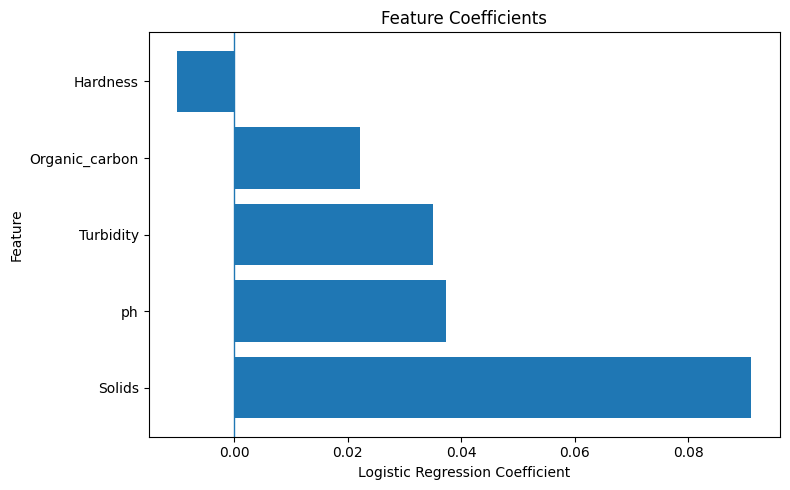

In [15]:
# Plot feature coefficients

plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients")

plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()


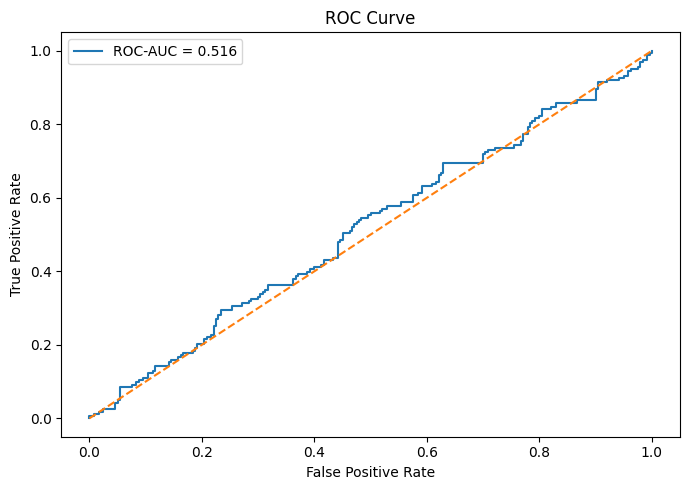

In [16]:
# Plot ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# Test the model with a sample water-quality input

# Input order:
# ph, Turbidity, Hardness, Solids, Organic_carbon

sample = pd.DataFrame([[
    7.0,       # pH
    4.0,       # Turbidity
    200.0,     # Hardness
    25000.0,   # Solids
    12.0       # Organic Carbon
]], columns=features)

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)[0]
probability = model.predict_proba(sample_scaled)[0][1]

if prediction == 1:
    print("Prediction: Potable")
else:
    print("Prediction: Not potable")

print("Potability Probability:", probability)


Prediction: Not potable
Potability Probability: 0.4059459502580341


In [18]:
# Save the trained model and scaler

joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save the feature order as well, which helps keep the API/app input consistent.
joblib.dump(features, "model_features.pkl")

print("Files saved successfully:")
print("- logistic_model.pkl")
print("- scaler.pkl")
print("- model_features.pkl")


Files saved successfully:
- logistic_model.pkl
- scaler.pkl
- model_features.pkl


## Model Input Order

The model expects exactly these five parameters in this order:

1. `ph`
2. `Turbidity`
3. `Hardness`
4. `Solids`
5. `Organic_carbon`

The original CSV can still contain all nine water-quality parameters. The model simply ignores the other columns during training.
